# Test 2 — Adquisición con OR_MASK (multitrigger)

Flujo:
1. DAC: seno 100 kHz en `OUT2`, DC fino (0.3 V) en `OUT1`.
2. Acquisition básica vía API `rp` (decimación, threshold, delay).
3. **OR_MASK** = `0xFFFF_FFFF` en `0x240` y `0x244` (canal 0 y 1) — escrito
   vía `/dev/mem` porque la API estándar no expone el nuevo registro.
4. Arm + trigger + lectura del buffer + lectura de debug regs.
5. Validación: alternar qué canal del DAC produce la señal y confirmar que
   el trigger sigue disparando (gracias a la OR de todas las fuentes).

In [ ]:
import time, mmap, os, struct
import numpy as np
from matplotlib import pyplot as plt
import rp

# === Cómo cargar un bitstream propio vía rp_overlay ===
# Hay que dejar en /opt/redpitaya/fpga/<nombre_proyecto>/ los archivos:
#   - fpga.bit.bin   (bitstream en formato Zynq con header)
#   - fpga.dtbo      (device tree overlay)
#
# Setup típico desde la Pitaya:
#   redpitaya> mkdir -p /opt/redpitaya/fpga/$(monitor -f)/MCA
#   redpitaya> cp /root/red_pitaya_top.bit.bin \
#                 /opt/redpitaya/fpga/$(monitor -f)/MCA/fpga.bit.bin
#   redpitaya> cp /root/devicetree.dtbo \
#                 /opt/redpitaya/fpga/$(monitor -f)/MCA/fpga.dtbo
#
# Luego desde Python:
#   from rp_overlay import overlay
#   fpga = overlay("MCA")          # ← NOMBRE del directorio, NO el .bit.bin
#
# Mientras desarrollás podés bypasear el overlay con fpgautil (solo carga
# el bitstream, NO el device tree — sirve para acceso /dev/mem directo):
#   !fpgautil -b /root/red_pitaya_top.bit.bin

rp.rp_Init()

# /dev/mem helper para la zona multitrigger (0x210, 0x214, 0x218, 0x21C, 0x240+)
SCOPE_PHYS = 0x4010_0000
SCOPE_SIZE = 0x30000
fd = os.open('/dev/mem', os.O_RDWR | os.O_SYNC)
scope = mmap.mmap(fd, SCOPE_SIZE, mmap.MAP_SHARED,
                  mmap.PROT_READ | mmap.PROT_WRITE, offset=SCOPE_PHYS)

def w32(off, v):
    scope[off:off+4] = struct.pack('<I', v & 0xFFFFFFFF)

def r32(off):
    return struct.unpack('<I', scope[off:off+4])[0]

OR_MASK_ALL = 0xFFFF_FFFF  # vector de 1: todas las fuentes habilitadas
N_BUF = 16384
FS    = 125e6              # Hz, sampling rate con decimación 1

In [19]:
# Comprobación de carga del bitstream
!fpgautil -b /root/red_pitaya_top.bit.bin
# Tenemos que hacer fpgautil -b top.bit.bin 

print(f'0x14  set_dec_ch0  = {r32(0x14):#010x}  (esperado tras reset: 0x00000001)')
print(f'0x114 set_dec_ch1  = {r32(0x114):#010x}  (esperado tras reset: 0x00000001)')
print(f'0x204 calib_gain_0 = {r32(0x204):#010x}  (esperado tras reset: 0x00008000)')
print(f'0x21C we_keep+dis  = {r32(0x21C):#010x}  (esperado tras reset: 0)')
print(f'0x240 trg_src_ch0  = {r32(0x240):#010x}')

Time taken to load BIN is 36.000000 Milli Seconds
BIN FILE loaded through FPGA manager successfully
0x14  set_dec_ch0  = 0x00000001  (esperado tras reset: 0x00000001)
0x114 set_dec_ch1  = 0x00000001  (esperado tras reset: 0x00000001)
0x204 calib_gain_0 = 0x00008000  (esperado tras reset: 0x00008000)
0x21C we_keep+dis  = 0x00000000  (esperado tras reset: 0)
0x240 trg_src_ch0  = 0x00000000


## DAC: sine ch2, DC fino ch1

In [ ]:
# DAC en modo CONTINUO con freqs independientes por canal.
#
# Confirmado leyendo /home/lorenzo/PI/RedPitaya/rp-api/api/src/:
#   - rp_GenMode(ch, RP_GEN_MODE_CONTINUOUS): apaga burst (count=0, delay=0,
#     repetitions=0). Por sí solo NO arranca la salida.
#   - rp_GenTriggerSource(ch, RP_GEN_TRIG_SRC_INTERNAL): escribe
#     triggerSelector=1 en el registro del gen. Le dice a la FSM qué fuente
#     de trigger usar, pero NO emite el pulso.
#   - rp_GenOutEnableSync(True): destraba el "force output to 0" — habilita
#     que la salida llegue al pin, pero NO arranca el sequencer.
#   - rp_GenTriggerOnly(ch) (= generate_Trigger): ESTO es lo que arranca el
#     sequencer. En CONTINUOUS corre para siempre tras este pulso; en BURST
#     dispara un burst por pulso.
#
# Por eso, aún en CONTINUO + INTERNAL, hay que pulsar TriggerOnly una vez
# para que la DAC empiece a emitir señal.

def _set_continuous(ch):
    """Forzar modo continuo (no burst). Tolerante a APIs que no exponen GenMode."""
    try:
        if hasattr(rp, 'rp_GenMode') and hasattr(rp, 'RP_GEN_MODE_CONTINUOUS'):
            rp.rp_GenMode(ch, rp.RP_GEN_MODE_CONTINUOUS)
    except Exception:
        pass

def configure_dac_continuous(sine_chs=None, freqs=None, dc_chs=None,
                              amp=1.0, dc=0.3):
    """
    sine_chs:  lista de canales con seno, ej: [1, 2], [1], [2], o None.
    freqs:     dict {1: f_ch1, 2: f_ch2} con la freq de cada canal en sine_chs.
    dc_chs:    lista de canales en DC (offset = dc), ej: [1] o None.
    amp:       amplitud del seno (V, max ~1.0).
    dc:        nivel DC (V).
    """
    sine_chs = sine_chs or []
    dc_chs   = dc_chs   or []
    freqs    = freqs    or {}

    rp.rp_GenReset()

    for c in sine_chs:
        ch = rp.RP_CH_1 if c == 1 else rp.RP_CH_2
        f  = freqs.get(c, 100_000)
        rp.rp_GenWaveform(ch, rp.RP_WAVEFORM_SINE)
        rp.rp_GenFreqDirect(ch, f)
        rp.rp_GenAmp(ch, amp)
        _set_continuous(ch)
        rp.rp_GenTriggerSource(ch, rp.RP_GEN_TRIG_SRC_INTERNAL)

    for c in dc_chs:
        ch = rp.RP_CH_1 if c == 1 else rp.RP_CH_2
        rp.rp_GenWaveform(ch, rp.RP_WAVEFORM_DC)
        rp.rp_GenAmp(ch, 0.0)
        rp.rp_GenOffset(ch, dc)
        _set_continuous(ch)
        rp.rp_GenTriggerSource(ch, rp.RP_GEN_TRIG_SRC_INTERNAL)

    # Habilita las salidas (destraba el output)
    rp.rp_GenOutEnableSync(True)

    # ARRANCA el sequencer una vez por canal configurado.
    # En CONTINUO esto inicia el output que después corre solo, sin más
    # triggers. Si lo omitís, el generador queda esperando y nunca emite señal.
    for c in sine_chs + dc_chs:
        ch = rp.RP_CH_1 if c == 1 else rp.RP_CH_2
        rp.rp_GenTriggerOnly(ch)

# Default: OUT1 seno 100 kHz, OUT2 seno 25 kHz (freqs distintas para validación)
configure_dac_continuous(sine_chs=[1, 2],
                          freqs={1: 100_000, 2: 25_000})
print('DAC continuo: OUT1=100kHz, OUT2=25kHz (arrancado con TriggerOnly)')

## ACQ base + OR_MASK + captura

In [57]:
def acq_base(thr=0.5, delay=0):
    rp.rp_AcqReset()
    rp.rp_AcqSetDecimation(rp.RP_DEC_1)
    rp.rp_AcqSetTriggerLevel(rp.RP_T_CH_1, thr)
    rp.rp_AcqSetTriggerLevel(rp.RP_T_CH_2, thr)
    rp.rp_AcqSetTriggerDelay(delay)

def set_or_mask(mask=OR_MASK_ALL):
    # escritura dispara new_trg_src y engancha la máscara
    w32(0x240, mask)
    w32(0x244, mask)
    rb0, rb1 = r32(0x240), r32(0x244)
    assert rb0 == mask, f'OR_MASK ch0 no latcheada: {rb0:#010x}'
    assert rb1 == mask, f'OR_MASK ch1 no latcheada: {rb1:#010x}'


def wait_triggered(timeout_ms=2000):
    for _ in range(timeout_ms):
        if rp.rp_AcqGetTriggerState()[1] == rp.RP_TRIG_STATE_TRIGGERED:
            return True
        time.sleep(0.001)
    return False

def wait_fill(timeout_ms=2000):
    for _ in range(timeout_ms):
        if rp.rp_AcqGetBufferFillState()[1]:
            return True
        time.sleep(0.001)
    return False

def read_buffers():
    fb1 = rp.fBuffer(N_BUF); rp.rp_AcqGetOldestDataV(rp.RP_CH_1, N_BUF, fb1)
    fb2 = rp.fBuffer(N_BUF); rp.rp_AcqGetOldestDataV(rp.RP_CH_2, N_BUF, fb2)
    d1 = np.fromiter((fb1[i] for i in range(N_BUF)), dtype=float, count=N_BUF)
    d2 = np.fromiter((fb2[i] for i in range(N_BUF)), dtype=float, count=N_BUF)
    return d1, d2

def debug_dump():
    print(f'  snapshot @0x218 = {r32(0x218):#010x}  (qué disparó)')
    print(f'  dis_act  @0x21C = {r32(0x21C):#010x}  (canales bloqueados)')
    print(f'  mask act ch0/ch1 = {r32(0x240):#010x} / {r32(0x244):#010x}')
    print(f'  shield   @0x214 = {r32(0x214):#010x}')

In [ ]:
# === Sanity check del ADC con SEÑAL EXTERNA o DAC ===
#
# CLAVE: si no se dispara un trigger, el bram_sm sigue escribiendo el buffer
# continuamente y la lectura desde SW agarra samples de DISTINTAS ventanas
# temporales pegados (genera "anchos variables" en cuadradas, períodos
# distintos en senos). Solución: forzar UN trigger SW para que el FSM
# complete una captura y se quede quieto, y recién ahí leer.
#
# Cómo dispara: ponemos OR_MASK con bit 0 (SW manual) + escribimos 0x04
# con valor 1 (= adc_trig_sw pulse). El multitrigger_trig_src ve el SW
# manual habilitado → trigger_event firme → bram_sm cuenta el delay y para.

def acq_capture_sw(decim=1, delay=N_BUF//2, timeout_ms=500):
    """Captura única forzada por SW trigger. Devuelve (d1, d2) consistentes
    (sin discontinuidades por overwrite mid-read)."""
    rp.rp_AcqReset()
    # decim
    if   decim == 1:    rp.rp_AcqSetDecimation(rp.RP_DEC_1)
    elif decim == 8:    rp.rp_AcqSetDecimation(rp.RP_DEC_8)
    elif decim == 64:   rp.rp_AcqSetDecimation(rp.RP_DEC_64)
    elif decim == 1024: rp.rp_AcqSetDecimation(rp.RP_DEC_1024)
    rp.rp_AcqSetTriggerDelay(delay)

    # Máscara con bit 0 = SW manual: el adc_trig_sw del 0x04 sí entra al OR
    w32(0x240, 1)
    w32(0x244, 1)

    rp.rp_AcqStart()
    time.sleep(0.01)

    # SW trigger: byte/canal == 0x01 en 0x04 → pulsa adc_trig_sw[0] y [1]
    # (lo escribimos en byte0 para ch0 y en byte1 para ch1)
    w32(0x04, 0x0000_0101)

    # Esperar a que el FSM diga "buffer lleno" → ya no escribe más, podemos leer.
    for _ in range(timeout_ms):
        if rp.rp_AcqGetBufferFillState()[1]:
            break
        time.sleep(0.001)

    d1, d2 = read_buffers()
    snap = r32(0x218)
    return d1, d2, snap

def adc_signal_check(channel=1, plot_n=2000):
    """Captura UNA ventana consistente y muestra forma + FFT.
    Si la señal viene de un generador externo, conectalo a IN1 o IN2."""
    d1, d2, snap = acq_capture_sw()
    d = d1 if channel == 1 else d2

    sig   = d - d.mean()
    fft   = np.abs(np.fft.rfft(sig))
    freqs = np.fft.rfftfreq(N_BUF, d=1/FS)
    f_fft = freqs[np.argmax(fft[1:]) + 1]

    sign = np.sign(d - d.mean())
    idx  = np.where(np.diff(sign) > 0)[0]
    f_zc = (1e6 / (np.diff(idx).mean() / FS * 1e6)) if len(idx) >= 2 else float('nan')

    print(f'IN{channel}:')
    print(f'  FFT pico      = {f_fft:>10.1f} Hz')
    print(f'  cruces 0 asc  = {f_zc:>10.1f} Hz   (debería matchear FFT)')
    print(f'  pico-pico     = {d.max()-d.min():.3f} V')
    print(f'  media         = {d.mean():+.3f} V')
    print(f'  snapshot @0x218 = {snap:#010x}  (debería tener el SW bit o el flanco que disparó)')

    fig, ax = plt.subplots(1, 2, figsize=(12, 3))
    ax[0].plot(d[:plot_n], label=f'IN{channel}')
    ax[0].axhline(d.mean(), color='gray', ls=':', lw=0.7)
    ax[0].set_title(f'IN{channel}: FFT={f_fft:.0f} Hz  zc={f_zc:.0f} Hz')
    ax[0].grid(True); ax[0].legend()

    ax[1].semilogy(freqs/1e3, fft / fft.max())
    ax[1].axvline(f_fft/1e3, color='r', ls='--', label=f'pico {f_fft/1e3:.1f} kHz')
    ax[1].set_xlim(0, min(FS/2/1e3, f_fft*5/1e3))
    ax[1].set_xlabel('freq (kHz)'); ax[1].set_ylabel('|FFT| norm')
    ax[1].grid(True); ax[1].legend(fontsize=8)
    plt.tight_layout(); plt.show()
    return d, f_fft

# Conectá tu generador externo a IN1 (y/o IN2). Cualquier waveform sirve.
adc_signal_check(channel=1)
adc_signal_check(channel=2)

In [ ]:
# === Debug completo del estado del trigger ===
# Imprime los regs relevantes para diagnosticar por qué un trigger no fira.

_SNAPSHOT_NAMES = ['sw_any',
                   'adc_p0','adc_p1','adc_p2','adc_p3',
                   'adc_n0','adc_n1','adc_n2','adc_n3',
                   'ext_p','ext_n','asg_p','asg_n',
                   'trig_ch0','trig_ch1','trig_ch2','trig_ch3']
def _decode_snap(s):
    return [n for i, n in enumerate(_SNAPSHOT_NAMES) if s & (1 << i)]

def debug_trigger():
    print('--- write-side (config) ---')
    print(f'  set_tresh ch0/ch1 @0x08/0x0C = {r32(0x08):#010x} / {r32(0x0C):#010x}')
    print(f'  set_hyst  ch0/ch1 @0x20/0x24 = {r32(0x20):#010x} / {r32(0x24):#010x}')
    print(f'  set_deb_len       @0x90     = {r32(0x90):#010x}')
    print(f'  trg_src_stored ch0/ch1 @0x240/0x244 = {r32(0x240):#010x} / {r32(0x244):#010x}')
    print(f'  shield_cfg            @0x210 = {r32(0x210):#010x}')
    print('--- run-time (status / debug) ---')
    print(f'  adc_state         @0x00 = {r32(0x00):#010x}  (config + trigger_status por canal)')
    print(f'  trg_state         @0x04 = {r32(0x04):#010x}  (set_trig_src[7:0] activo por canal en bytes)')
    print(f'  shield runtime    @0x214 = {r32(0x214):#010x}  ({{active, cnt[15:0]}})')
    snap = r32(0x218)
    print(f'  snapshot          @0x218 = {snap:#010x}  -> {_decode_snap(snap)}')
    dis_we = r32(0x21C)
    print(f'  dis+we_keep       @0x21C = {dis_we:#010x}  dis_act={dis_we & 0xF:#x} we_keep={(dis_we>>4) & 0xF:#x}')
    print(f'  wp_trig ch0/ch1   @0x1C/0x11C = {r32(0x1C):#010x} / {r32(0x11C):#010x}')
    print(f'  wp_cur  ch0/ch1   @0x18/0x118 = {r32(0x18):#010x} / {r32(0x118):#010x}')

debug_trigger()

triggered=False   buffer_full=False
  snapshot @0x218 = 0x00000000  (qué disparó)
  dis_act  @0x21C = 0x00000000  (canales bloqueados)
  mask act ch0/ch1 = 0xffffffff / 0xffffffff
  shield   @0x214 = 0x00000000


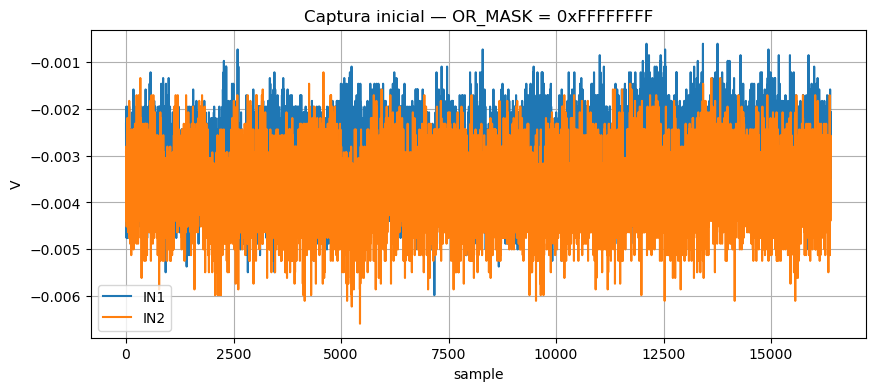

In [64]:
# Captura inicial: sine en OUT2, DC en OUT1, OR_MASK = todo
acq_base(thr=0.5, delay=0)
set_or_mask(OR_MASK_ALL)

rp.rp_AcqStart()
time.sleep(0.05)

# Trigger interno de los generadores
# Que hace esto? Genera un trigger externo en alguno de los canales?
#rp.rp_GenTriggerOnly(rp.RP_CH_1)
#rp.rp_GenTriggerOnly(rp.RP_CH_2)

# Trigerea con rp_AcqGetTriggerState()[1], de forma que si tengo un nivel 
# de continua va a empezar apenas pueda y creo que puede no verse 
# la inicialización de la senoideal

trg_ok = wait_triggered()
buf_ok = wait_fill()
print(f'triggered={trg_ok}   buffer_full={buf_ok}')
debug_dump()

d1, d2 = read_buffers()
plt.figure(figsize=(10, 4))
plt.plot(d1, label='IN1')
plt.plot(d2, label='IN2')
plt.xlabel('sample'); plt.ylabel('V'); plt.legend(); plt.grid(True)
plt.title('Captura inicial — OR_MASK = 0xFFFFFFFF'); plt.show()

## Validación — alternar canales del DAC

Con OR_MASK = todas las fuentes habilitadas, el trigger debe disparar
independientemente de cuál canal de salida del DAC esté generando la señal
viva. Se corren 3 casos y se reporta `triggered` + `snapshot`.

In [7]:
def run_case(label, sine_ch, dc_ch):
    configure_dac(sine_ch=sine_ch, dc_ch=dc_ch)
    acq_base(thr=0.5, delay=0)
    set_or_mask(OR_MASK_ALL)
    rp.rp_AcqStart()
    time.sleep(0.05)
    rp.rp_GenTriggerOnly(rp.RP_CH_1)
    rp.rp_GenTriggerOnly(rp.RP_CH_2)
    ok = wait_triggered()
    snap = r32(0x218)
    print(f'[{label}] sine={sine_ch} dc={dc_ch}   triggered={ok}   snapshot=0x{snap:08x}')
    return ok, snap

res_A = run_case('A', sine_ch=2,      dc_ch=1)
res_B = run_case('B', sine_ch=1,      dc_ch=2)
res_C = run_case('C', sine_ch='both', dc_ch=None)

all_ok = all(r[0] for r in (res_A, res_B, res_C))
print('\nVALIDACIÓN OR:', 'PASS' if all_ok else 'FAIL')

[A] sine=2 dc=1   triggered=True   snapshot=0x00001000
[B] sine=1 dc=2   triggered=True   snapshot=0x00001000
[C] sine=both dc=None   triggered=True   snapshot=0x00001000

VALIDACIÓN OR: PASS


## Decodificación del snapshot @0x218

Layout (17 bits): `{trig_ch[3:0], asg_n, asg_p, ext_n, ext_p, adc_n[3:0], adc_p[3:0], sw_any}`.
Bits desde el LSB:

| bit | fuente |
|-----|--------|
| 0   | SW manual (cualquier canal) |
| 1..4 | ADC posedge ch0..ch3 |
| 5..8 | ADC negedge ch0..ch3 |
| 9   | ext posedge |
| 10  | ext negedge |
| 11  | ASG posedge |
| 12  | ASG negedge |
| 13..16 | trig_ch[0..3] (cadena del otro scope) |

In [6]:
def decode_snapshot(s):
    names = ['sw_any',
             'adc_p0','adc_p1','adc_p2','adc_p3',
             'adc_n0','adc_n1','adc_n2','adc_n3',
             'ext_p','ext_n','asg_p','asg_n',
             'trig_ch0','trig_ch1','trig_ch2','trig_ch3']
    return [n for i, n in enumerate(names) if s & (1 << i)]

for label, (ok, snap) in [('A', res_A), ('B', res_B), ('C', res_C)]:
    print(f'[{label}] snap=0x{snap:08x}  ->  {decode_snapshot(snap)}')

[A] snap=0x00001000  ->  ['asg_n']
[B] snap=0x00001000  ->  ['asg_n']
[C] snap=0x00001000  ->  ['asg_n']


## Validación de tiempos de trigger

DAC en continuo con freqs distintas por canal. Se mide:

- **Caso A**: máscara OR solo sensible al ADC ch0 posedge (bit 1) → los
  intervalos entre cruces ascendentes deben coincidir con `1/f_ch0`.
- **Caso B**: máscara OR solo sensible al ADC ch1 posedge (bit 3) → los
  intervalos deben coincidir con `1/f_ch1`.
- **Caso C**: máscara OR con ambos canales habilitados + `adc_we_keep=1`
  (modo continuo de captura del scope) → loop de N capturas y se mide la
  freq efectiva de eventos. La OR de dos fuentes asíncronas dispara con
  cada flanco ⇒ período efectivo ≈ `min(1/f_ch0, 1/f_ch1)`.

Mapa de la máscara (32 bits, OR de las clases habilitadas):
| bit | fuente |
|-----|--------|
| 1   | ADC ch0 posedge |
| 2   | ADC ch0 negedge |
| 3   | ADC ch1 posedge |
| 4   | ADC ch1 negedge |
| 9   | ext posedge |
| 11  | ASG posedge |
| 13..16 | trig_ch[0..3] |

In [ ]:
# --- Helpers de timing ---

def edge_periods_us(samples, level=0.5, edge='rising'):
    """Períodos (µs) entre cruces consecutivos del nivel, en el sentido dado."""
    s = np.asarray(samples, dtype=float)
    sign = np.sign(s - level)
    if edge == 'rising':
        idx = np.where(np.diff(sign) > 0)[0]
    else:
        idx = np.where(np.diff(sign) < 0)[0]
    if len(idx) < 2:
        return np.array([])
    return np.diff(idx) / FS * 1e6  # µs

def capture_once(thr=0.5, delay=0, mask_ch0=OR_MASK_ALL, mask_ch1=OR_MASK_ALL,
                  timeout_ms=500):
    """Una captura (single-shot). Devuelve (d1, d2, snapshot, triggered_ok)."""
    rp.rp_AcqReset()
    rp.rp_AcqSetDecimation(rp.RP_DEC_1)
    rp.rp_AcqSetTriggerLevel(rp.RP_T_CH_1, thr)
    rp.rp_AcqSetTriggerLevel(rp.RP_T_CH_2, thr)
    rp.rp_AcqSetTriggerDelay(delay)
    w32(0x240, mask_ch0)
    w32(0x244, mask_ch1)
    rp.rp_AcqStart()
    time.sleep(0.01)
    ok_trg  = wait_triggered(timeout_ms=timeout_ms)
    ok_fill = wait_fill(timeout_ms=timeout_ms)
    snap = r32(0x218)
    d1, d2 = read_buffers()
    return d1, d2, snap, (ok_trg and ok_fill)

def trigger_loop(n_caps=20, mask_ch0=OR_MASK_ALL, mask_ch1=OR_MASK_ALL,
                 thr=0.5, delay=0, timeout_ms=500):
    """N capturas en modo continuo (adc_we_keep=1).

    OJO: rp_AcqGetTriggerState es STICKY — una vez TRIGGERED queda TRIGGERED
    hasta el próximo arm. Para detectar triggers NUEVOS en we_keep=1 hay que
    pollear adc_wp_trig @0x1C (puntero al sample del trigger), que cambia
    con cada disparo nuevo.

    Devuelve lista de (t_perf_ns, wp_trig, snap, new_trigger_detected).
    """
    # we_keep[ch0]=1 (byte0 bit3) + we_keep[ch1]=1 (byte1 bit3) → 0x08 en cada byte
    w32(0x00, 0x0000_0808)

    rp.rp_AcqSetDecimation(rp.RP_DEC_1)
    rp.rp_AcqSetTriggerLevel(rp.RP_T_CH_1, thr)
    rp.rp_AcqSetTriggerLevel(rp.RP_T_CH_2, thr)
    rp.rp_AcqSetTriggerDelay(delay)
    w32(0x240, mask_ch0)
    w32(0x244, mask_ch1)
    rp.rp_AcqStart()

    out = []
    wp_prev = r32(0x1C)
    t0 = time.perf_counter_ns()
    for _ in range(n_caps):
        ok = False
        for _ in range(timeout_ms):
            wp_cur = r32(0x1C)
            if wp_cur != wp_prev:
                ok = True
                break
            time.sleep(0.001)
        t = time.perf_counter_ns() - t0
        snap = r32(0x218)
        out.append((t, wp_cur, snap, ok))
        wp_prev = wp_cur
        # Re-habilitar trigger en ambos canales (byte0 + byte1, bit0)
        w32(0x94, 0x0000_0101)
    return out

print('helpers definidos: edge_periods_us, capture_once, trigger_loop')

In [ ]:
# === Caso A: máscara solo ADC ch0 posedge (bit 1) ===
# Esperado: intervalos entre cruces ascendentes de IN1 ≈ 1/f_ch0 = 10 µs (100 kHz).
configure_dac_continuous(sine_chs=[1, 2], freqs={1: 100_000, 2: 25_000})
MASK_CH0_PE = 1 << 1
d1, d2, snap, ok = capture_once(thr=0.5, mask_ch0=MASK_CH0_PE, mask_ch1=MASK_CH0_PE)
print(f'[A] triggered={ok}   snapshot=0x{snap:08x} -> {decode_snapshot(snap)}')

per_us = edge_periods_us(d1, level=0.5, edge='rising')
exp_us = 1e6 / 100_000
print(f'[A] N cruces={len(per_us)+1}  período medio = {per_us.mean():.3f} µs '
      f'(esperado {exp_us:.3f} µs, error = {(per_us.mean()-exp_us)/exp_us*100:.2f}%)')

plt.figure(figsize=(10, 3))
plt.plot(d1[:2000], label='IN1 100kHz')
plt.axhline(0.5, color='r', ls='--', lw=0.7); plt.legend(); plt.grid(True)
plt.title('Caso A — captura disparada por flanco ascendente IN1'); plt.show()

In [ ]:
# === Caso B: máscara solo ADC ch1 posedge (bit 3) ===
# Esperado: intervalos entre cruces ascendentes de IN2 ≈ 1/f_ch1 = 40 µs (25 kHz).
MASK_CH1_PE = 1 << 3
d1, d2, snap, ok = capture_once(thr=0.5, mask_ch0=MASK_CH1_PE, mask_ch1=MASK_CH1_PE)
print(f'[B] triggered={ok}   snapshot=0x{snap:08x} -> {decode_snapshot(snap)}')

per_us = edge_periods_us(d2, level=0.5, edge='rising')
exp_us = 1e6 / 25_000
if len(per_us):
    print(f'[B] N cruces={len(per_us)+1}  período medio = {per_us.mean():.3f} µs '
          f'(esperado {exp_us:.3f} µs, error = {(per_us.mean()-exp_us)/exp_us*100:.2f}%)')
else:
    print('[B] sin suficientes cruces — la freq es baja vs N_BUF')

plt.figure(figsize=(10, 3))
plt.plot(d2, label='IN2 25kHz')
plt.axhline(0.5, color='r', ls='--', lw=0.7); plt.legend(); plt.grid(True)
plt.title('Caso B — captura disparada por flanco ascendente IN2'); plt.show()

In [ ]:
# === Caso C: máscara OR ch0+ch1 posedge + loop continuo (adc_we_keep=1) ===
# Ahora el loop detecta triggers NUEVOS via cambios de adc_wp_trig @0x1C
# (rp_AcqGetTriggerState es sticky en we_keep). El dt medido sigue siendo
# una cota superior (incluye latencia del polling SW + bus PS↔PL ≈ µs).
MASK_AB = (1 << 1) | (1 << 3)
N_CAPS  = 30
events = trigger_loop(n_caps=N_CAPS,
                       mask_ch0=MASK_AB, mask_ch1=MASK_AB,
                       thr=0.5, timeout_ms=200)

ok_count = sum(1 for _, _, _, ok in events if ok)
ts_ns    = np.array([t  for t, _, _, _ in events])
wps      = np.array([wp for _, wp, _, _ in events])
snaps    = [s for _, _, s, _ in events]
dts_us   = np.diff(ts_ns) / 1000.0  # ns → µs

print(f'[C] {ok_count}/{N_CAPS} triggers nuevos detectados')
print(f'[C] dt entre triggers (µs): media={dts_us.mean():.2f}  '
      f'min={dts_us.min():.2f}  max={dts_us.max():.2f}')
print(f'[C] wp_trig (muestra dentro del buffer) últimos 5: {wps[-5:]}')
print(f'[C] snapshots únicos: {set(snaps)} -> {[decode_snapshot(s) for s in set(snaps)]}')
print(f'[C] esperado del trigger HW: ~10 µs (100 kHz domina). '
      f'Lo medido es la latencia SW; usar wp_trig consecutivos para timing real.')

plt.figure(figsize=(10, 3))
plt.plot(dts_us, 'o-')
plt.axhline(10.0, color='r', ls='--', label='1/100 kHz = 10 µs (HW)')
plt.xlabel('captura #'); plt.ylabel('dt SW entre triggers (µs)')
plt.legend(); plt.grid(True); plt.title('Caso C — loop multi-trigger'); plt.show()

# Limpieza: apagar modo continuo (we_keep=0) para no dejar el scope armado.
w32(0x00, 0x0000_0000)

In [7]:
scope.close()
os.close(fd)
rp.rp_Release()
print('cerrado')

cerrado
